# Figure S3 -- Grid search over mutagenesis-fit model hyperparameters (MSE)

Visualizes the Ridge-regression MSE grid search over pooling method (avg/max), activation
function (ReLU/sigmoid), motif-aggregation method (mean/max), activation threshold, and
ridge alpha, for the mutagenesis-fit model (Methods 2.7, 309 bp mutagenized regions). The
optimum for each of the 8 pooling/activation/motif-agg combinations is boxed in blue.

**Required inputs** (place in `../output_files/`): one `Converted_RidgeCV_MutModel_gridsearch_
293tfs_results_bin309bp_{relu,sigmoid}_S0.pkl` file for each activation function (2 files
total), produced by running `mutagen_grid_search.py` for each activation function.

In [ ]:
import os
import glob
import itertools
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import patches

OUTPUT_DIR = '../output_files'
FIGURES_DIR = '../figures'
os.makedirs(FIGURES_DIR, exist_ok=True)

pool_functions = ['avg', 'max']
activation_functions = ['relu', 'sigmoid']
motif_agg_methods = ['avg', 'max']
strand_agg = 'sum'  # S0
S = 'S0'
bin_len = 309
n_tfs = 293

alpha_list = [0] + np.logspace(-2, 4, 13, base=10).tolist()
activation_thrs = [-2, 0, 2, 4, 6, 8, 10, 12, 14, 16]

In [ ]:
def find_best_config(bin_len, relu_list, metric_name='MSE'):
    """Load the cached grid-search results for each activation function at this bin
    length (each file already covers both pooling methods and both motif-agg methods),
    and report the best (relu_thr, alpha) configuration for each of the 8
    pooling/activation/motif-agg combinations, plus the single overall best."""
    metric = 0 if metric_name == 'MSE' else (1 if metric_name == 'PCC' else 2)
    all_results = {}
    for act_f in activation_functions:
        # Glob with an optional prefix: cached results may be shipped as
        # "Converted_..." (re-pickled under a different numpy version for
        # portability) or produced fresh (no prefix) by running mutagen_grid_search.py.
        pattern = f'{OUTPUT_DIR}/*RidgeCV_MutModel_gridsearch_{n_tfs}tfs_results_bin{bin_len}bp_{act_f}_{S}.pkl'
        matches = glob.glob(pattern)
        if not matches:
            raise FileNotFoundError(
                f"No grid-search results found matching {pattern}. "
                "Run mutagen_grid_search.py for this activation function first."
            )
        with open(matches[0], 'rb') as f:
            results = pickle.load(f)
        for key, value in results['results'].items():
            all_results.setdefault(key, []).append(value)

    heatmap_data = np.zeros((8, len(relu_list), 5, len(alpha_list)))
    c = 0
    for pool_f, act_f, motif_agg in itertools.product(pool_functions, activation_functions, motif_agg_methods):
        for i, relu_thr in enumerate(relu_list):
            heatmap_data[c, i, :, :] = all_results[(relu_thr, pool_f, act_f, strand_agg, motif_agg)][0][metric]
        c += 1

    sub_plots = np.mean(heatmap_data, axis=2)  # average over the 5 CV folds

    combos = list(itertools.product(['AvgPooling', 'MaxPooling'], ['ReLU', 'Sigmoid'], ['Motifs_mean', 'Motifs_max']))
    opt_values = np.min(sub_plots, axis=(1, 2)) if metric_name == 'MSE' else np.max(sub_plots, axis=(1, 2))
    flat_idx = np.argmin(sub_plots.reshape(8, -1), axis=1) if metric_name == 'MSE' else np.argmax(sub_plots.reshape(8, -1), axis=1)
    rows, cols = np.unravel_index(flat_idx, (len(relu_list), len(alpha_list)))

    for i in range(8):
        print(f"{combos[i]}: Optimum={opt_values[i]:.4f} at Act_thr{relu_list[rows[i]]}, Alpha={alpha_list[cols[i]]}")

    best_i = np.argmin(opt_values) if metric_name == 'MSE' else np.argmax(opt_values)
    print(f"Overall best configuration for bin{bin_len}bp-{S}: {combos[best_i]} "
          f"with Optimum={opt_values[best_i]:.4f} at Act_thr{relu_list[rows[best_i]]}, Alpha={alpha_list[cols[best_i]]}")

    return sub_plots


def plot_heatmaps_MSE(sub_plots, alpha_list, relu_list, metric_name='MSE', vmin_max=(0.23, 0.3)):
    fig, axes = plt.subplots(2, 4, figsize=(20, 8))
    fig.suptitle(f'Mutagenesis model ({metric_name})', fontsize=16, fontweight='bold')
    axes = axes.flatten()
    combos = list(itertools.product(['AvgPooling', 'MaxPooling'], ['ReLU', 'Sigmoid'], ['Motifs_mean', 'Motifs_max']))
    for i, data in enumerate(sub_plots):
        sns.heatmap(data, xticklabels=alpha_list, yticklabels=relu_list, cmap='hot',
                    vmin=vmin_max[0], vmax=vmin_max[1], ax=axes[i], cbar=True)
        opt_y, opt_x = (np.unravel_index(np.argmin(data, axis=None), data.shape) if metric_name == 'MSE'
                        else np.unravel_index(np.argmax(data, axis=None), data.shape))
        axes[i].add_patch(patches.Rectangle((opt_x, opt_y), 1, 1, edgecolor='blue', facecolor='none',
                                             linewidth=3, clip_on=False))
        axes[i].set_title(f'{combos[i][0]}, {combos[i][1]}, {combos[i][2]}', fontsize=16)
        axes[i].set_xlabel('Alpha Values', fontsize=14)
        axes[i].set_ylabel('ReLU Thresholds', fontsize=14)
        labels = [0] + [f'$10^{{{np.log10(a)}}}$' for a in alpha_list[1:]]
        axes[i].set_xticklabels(labels, rotation=45, ha='right')

    plt.tight_layout()
    fig.savefig(f'{FIGURES_DIR}/figS3_mutagenesis_grid_search_heatmaps_{metric_name}.pdf',
                dpi=300, bbox_inches='tight')
    plt.show()

## Figure S3 -- MSE heatmap, mutagenesis-fit model (309 bp)

('AvgPooling', 'ReLU', 'Motifs_mean'): Optimum=0.2200 at Act_thr4, Alpha=0.03162277660168379
('AvgPooling', 'ReLU', 'Motifs_max'): Optimum=0.2262 at Act_thr4, Alpha=0.1
('AvgPooling', 'Sigmoid', 'Motifs_mean'): Optimum=0.2352 at Act_thr6, Alpha=0.01
('AvgPooling', 'Sigmoid', 'Motifs_max'): Optimum=0.2355 at Act_thr8, Alpha=0.01
('MaxPooling', 'ReLU', 'Motifs_mean'): Optimum=0.2270 at Act_thr2, Alpha=1000.0
('MaxPooling', 'ReLU', 'Motifs_max'): Optimum=0.2296 at Act_thr6, Alpha=3162.2776601683795
('MaxPooling', 'Sigmoid', 'Motifs_mean'): Optimum=0.2283 at Act_thr8, Alpha=10.0
('MaxPooling', 'Sigmoid', 'Motifs_max'): Optimum=0.2321 at Act_thr10, Alpha=31.622776601683793
Overall best configuration for bin309bp-S0: ('AvgPooling', 'ReLU', 'Motifs_mean') with Optimum=0.2200 at Act_thr4, Alpha=0.03162277660168379


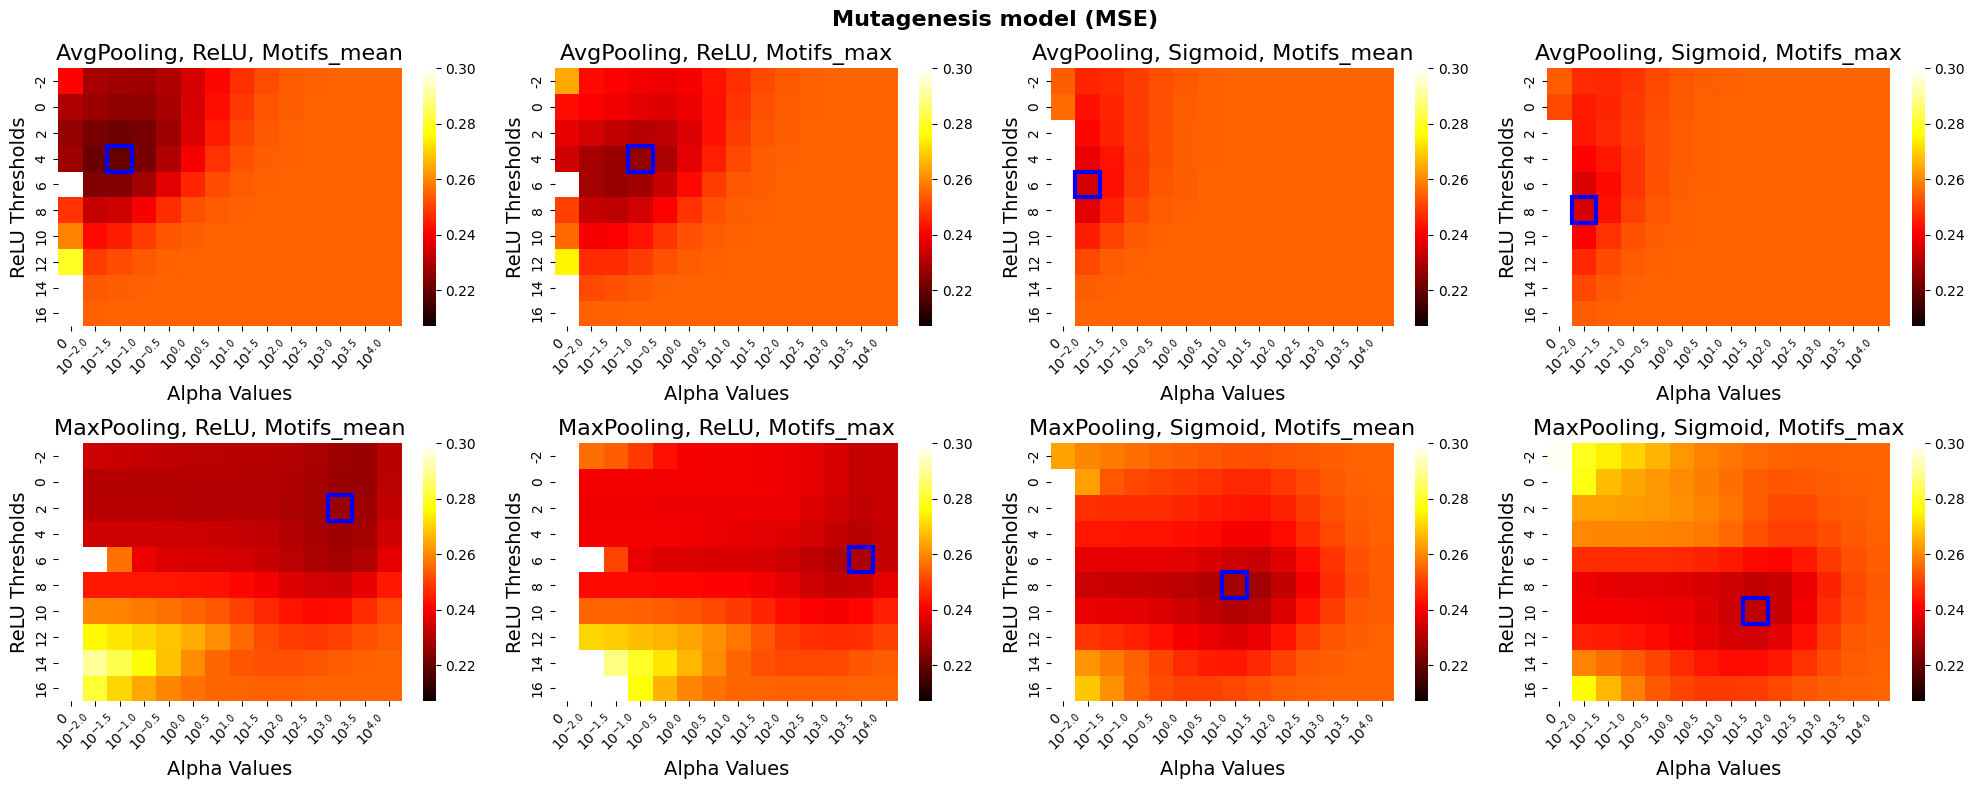

In [17]:
metric_ = 'MSE'
vmin_max = (0.3, 0.23)

sub_plots = find_best_config(bin_len=bin_len, relu_list=activation_thrs, metric_name=metric_)
plot_heatmaps_MSE(sub_plots, alpha_list, activation_thrs, metric_name=metric_, vmin_max=vmin_max)